# Predicción de incendios en la Patgaonia Andina.

**Autor:** Claudio Ezequiel Villagra Turco  
**Institución:** Universidad Nacional Guillermo Brown (UNaB)  
**Fecha:** Q4 2025  
**Correo electrónico:** ezequiel26.92@gmail.com 

---

## Resumen



---

## 1. Introducción

### 1.1. Contexto y Justificación
Por medio de esta investigación se busca abordar el fenómeno de incendios forestales en la Patagonia Andina a partir de un enfoque basado en la recopilación de datos. A continuación, se establecen los objetivos que darán lugar al desarrollo del trabajo, orientados tanto a la comprensión de los factores asociados a la aparición de focos de calor como al diseño de herramientas que permitan su detección y predicción.


### 1.2. Objetivos
#### 1.2.1. Objetivo General
Estudiar y comprender los incendios forestales de la Patagonia Andina que tienen lugar durante epocas de verano analizando los factores determinantes, evaluando su relación con la ocurrencia de incendios y explorar su potencial en la construcción de modelos predictivos.

#### 1.2.2. Objetivos Específicos
1. Recopilar y sistematizar la información necesaria y disponible para el desarrollo del proyecto, incluyendo datos satelitales, climatológicos y ambientales.
2. Realizar un análisis exploratorio de los datos recopilados para identificar patrones y correlaciones entre las variables estudiadas y la ocurrencia de incendios.
3. Implementar modelos de Machine Learning que permitan identificar focos activos y predecir la probabilidad de nuevos focos en una región específica.
4. Evaluar la efectividad de los modelos desarrollados mediante la comparación de sus predicciones con datos históricos de incendios.


## 2. Preparación


### 2.1 - Configuración de entorno.

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import logging
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd


sys.path.append('../scripts')

from datetime import datetime
from tqdm import tqdm
from project_config import ProjectConfig as cfg


### 2.2 - Utilidades.


#### 2.2.1 - Mapa de focos de calor.

In [ ]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point, box

def detection_map2(processed_data, bbox=cfg.BBOX):
    """
    Genera gráficos a partir del dataset fusionado ERA5 + FIRMS:
      - Serie temporal semanal de incendios (suma de n_fires)
      - Mapa de ubicaciones de incendios (celdas ERA5 con n_fires > 0)
    """

    # Asegurar que era5_time sea datetime
    processed_data['era5_time'] = pd.to_datetime(processed_data['acq_datetime'])

    # --------------------------
    # Serie temporal semanal
    # --------------------------
    weekly_counts = (
        processed_data
        .set_index("era5_time")
        .resample("W")['n_fires']
        .sum()   # suma de focos detectados
    )

    # --------------------------
    # Mapa de detecciones
    # --------------------------
    # Usar sólo celdas con incendios
    fire_points = processed_data[processed_data['n_fires'] > 0].copy()

    geometry = [Point(xy) for xy in zip(fire_points.longitude, fire_points.latitude)]
    gdf = gpd.GeoDataFrame(fire_points, geometry=geometry, crs="EPSG:4326")

    # Pasar a Web Mercator
    gdf_web = gdf.to_crs(epsg=3857)

    # Construir polígono del bbox
    bbox_poly = box(*bbox)
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326").to_crs(epsg=3857)

    # --------------------------
    # Figura
    # --------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # --- Gráfico semanal ---
    weekly_counts.plot(
        ax=ax1,
        kind="line",
        marker="o",
        color="firebrick",
        linewidth=2,
        title="Incendios detectados por semana"
    )
    ax1.tick_params(axis="x", rotation=45)
    ax1.set_ylabel("Cantidad de focos")
    ax1.grid(True, linestyle="--", alpha=0.6)

    # --- Mapa ---
    bbox_gdf.boundary.plot(ax=ax2, color="blue", linewidth=2, label="BBOX")

    gdf_web.plot(
        ax=ax2,
        column="n_fires",
        cmap="Reds",
        markersize=30,
        alpha=0.7,
        legend=True,
        legend_kwds={"label": "Número de focos"}
    )

    # Añadir mapa base OSM
    ctx.add_basemap(ax2, source=ctx.providers.OpenStreetMap.Mapnik)

    # Ajustar vista al bbox
    ax2.set_xlim(bbox_gdf.total_bounds[0], bbox_gdf.total_bounds[2])
    ax2.set_ylim(bbox_gdf.total_bounds[1], bbox_gdf.total_bounds[3])

    ax2.set_title("Ubicación de incendios (celdas ERA5)")
    ax2.legend()

    plt.tight_layout()
    plt.show()



In [ ]:
import contextily as ctx
from shapely.geometry import Point, box

def detection_map(processed_data) : 
    # Crear GeoDataFrame con puntos
    geometry = [Point(xy) for xy in zip(processed_data.longitude, processed_data.latitude)]
    gdf = gpd.GeoDataFrame(processed_data, geometry=geometry, crs="EPSG:4326")

    # Pasar a Web Mercator para usar con contextily
    gdf_web = gdf.to_crs(epsg=3857)

    # Construir polígono del bbox
    bbox_poly = box(*cfg.BBOX) 
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326").to_crs(epsg=3857)

    # Figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de líneas semanal
    weekly_counts = processed_data.set_index("acq_datetime").resample("W").size()

    weekly_counts.plot(
        ax=ax1, 
        kind="line", 
        marker="o", 
        color="steelblue", 
        linewidth=2, 
        title="Detecciones por semana"
    )
    ax1.tick_params(axis="x", rotation=45)
    ax1.set_ylabel("Cantidad de detecciones")
    ax1.grid(True, linestyle="--", alpha=0.6)


    # Mapa de detecciones
    bbox_gdf.boundary.plot(ax=ax2, color="blue", linewidth=2, label="BBOX")
    gdf_web.plot(ax=ax2, color='red', markersize=8, alpha=0.6, label='Detecciones')

    # Añadir mapa base OSM
    ctx.add_basemap(ax2, source=ctx.providers.OpenStreetMap.Mapnik)

    # Ajustar vista al bbox
    ax2.set_xlim(bbox_gdf.total_bounds[0], bbox_gdf.total_bounds[2])
    ax2.set_ylim(bbox_gdf.total_bounds[1], bbox_gdf.total_bounds[3])

    ax2.set_title("Ubicación de focos de incendio")
    ax2.legend()

    plt.tight_layout()
    plt.show()


## 3. Desarrollo


### 3.1 - Recopilación y sistematización de la información.


#### 3.1.1 - Articulos de Interés

- [Este articulo oficial](https://nahuelhuapi.gov.ar/focos-de-incendio-en-la-zona-de-lago-los-manzanos-en-cercanias-a-lago-martin/) es el primer reporte de detección de incendio emitido por las autoridades del Parque Nacional Nahuel Huapi el Jueves 26 de diciembre del 2024.

- [Este articulo periodistico](https://www.diarioandino.com.ar/noticias/2024/12/28/229751-el-incendio-en-el-lago-martin-ya-arraso-mas-de-1450-hectareas-de-bosque-nativo) evidencia la escalada del fuego en la zona sólo en los primeros 3 días desde su inicio, corresponde al Sábado 28 de diciembre del 2024.

- [Esta sección](https://confluence.ecmwf.int/display/CKB/ERA5%3A+What+is+the+spatial+reference) de la base de conocimiento de Copernicus tiene información acerca del sistema de coordenadas y una recomendación para la interpolacion de los datos.


#### 3.1.2 - Focos de Incendio (NASA FIRMS)

In [ ]:
from firms_tools import FIRMSTools

Mediante las FIRMSTools se puede hacer la descarga de datos que representan puntos de la región de estudio (la cual se encuentra configurada en project_config.py) donde se ha detectado un foco de incendio luego del pre-procesamiento de los datos de satelite.

La fución recibe las fuentes que están disponibles en el web service de la NASA son:
- ALL - all available sensors
- LANDSAT_NRT (LANDSAT 8/9)
- MODIS_NRT (MODIS Near Real-Time)
- MODIS_SP (MODIS Standard Processing) - [Descripción](https://www.earthdata.nasa.gov/data/catalog/lancemodis-mcd14dl-6.1nrt#ed-firms-attributes) || [Guía de usuario](https://www.earthdata.nasa.gov/sites/default/files/imported/MODIS_C6_Fire_User_Guide_B.pdf)
- VIIRS_NOAA20_NRT (VIIRS NOAA-20 Near Real-Time)
- VIIRS_NOAA20_SP (VIIRS NOAA-20 Standard Processing) - [Descripción](https://www.earthdata.nasa.gov/data/catalog/lancemodis-vj114imgtdl-nrt-2)
- VIIRS_NOAA21_NRT (VIIRS NOAA-21 Near Real-Time)
- VIIRS_SNPP_NRT (VIIRS Suomi-NPP Near Real-Time)
- VIIRS_SNPP_SP (VIIRS Suomi-NPP Standard Processing) - [Descripción](https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/viirs/)

Para este estudio se obtendrá información ya procesada (SP) dado que no aportaría valor acceder a información en tiempo real (NRT).

In [ ]:
# Obtención de datos en bruto desde FIRMS.
get_from_sources = ['MODIS_SP', 'VIIRS_NOAA20_SP', 'VIIRS_SNPP_SP']
firms = FIRMSTools()
raw_data = firms.get_fire_data(get_from_sources)

En [este enlace](https://www.earthdata.nasa.gov/data/tools/firms/active-fire-data-attributes-modis-viirs) se puede acceder al detalle de los atributos para cada fuente de información.

In [ ]:
# Arrays de selección y orden de columnas.
modis_cols = ['latitude', 'longitude', 'brightness', 'acq_datetime', 'confidence', 'bright_t31', 'frp', 'daynight']
modis_cols_reorder = ['acq_datetime', 'latitude', 'longitude', 'brightness', 'bright_t31', 'frp', 'daynight', 'confidence']

viirs_cols = ['latitude', 'longitude', 'bright_ti4', 'acq_datetime', 'confidence', 'bright_ti5', 'frp', 'daynight']
viirs_cols_reorder = ['acq_datetime', 'latitude', 'longitude', 'bright_ti4', 'bright_ti5', 'frp', 'daynight', 'confidence']


##### 3.1.2.1 - MODIS SP

In [ ]:
df_modis_sp = pd.read_csv(os.path.join(f'{cfg.DATA_RAW}/firms', 'firms_MODIS_SP_2024-12-01_2025-03-31.csv'))
df_modis_sp = firms.process_fire_data(df_modis_sp)

# Transformación de variables.
df_modis_sp['bright_t31'] = df_modis_sp['bright_t31'].apply(kelvin_to_celsius)

df_modis_sp = df_modis_sp[modis_cols]
df_modis_sp = df_modis_sp[modis_cols_reorder]
# df_modis_sp.head()
# detection_map(df_modis_sp)


##### 3.1.2.2 - NOAA20 SP

In [ ]:
df_noaa20_sp = pd.read_csv(os.path.join(f'{cfg.DATA_RAW}/firms', 'firms_VIIRS_NOAA20_SP_2024-12-01_2025-03-31.csv'))
df_noaa20_sp = firms.process_fire_data(df_noaa20_sp)


##### 3.1.2.3 - SNPP SP

In [ ]:
df_snpp_sp = pd.read_csv(os.path.join(f'{cfg.DATA_RAW}/firms', 'firms_VIIRS_SNPP_SP_2024-12-01_2025-03-31.csv'))
df_snpp_sp = firms.process_fire_data(df_snpp_sp)


#### 3.1.3 - Información meteorologíca. (COPERNICUS LAND Y LEVELS)

In [ ]:
from copernicus_tools import CopernicusTools


##### 3.1.3.1 - Copernicus ERA5 Levels

Utilizando CopernicusTools se puede acceder a los datos provistos por el programa de observación terrestsre (Copernicus) de la Union Europea. Está información se obtendrá haciendo uso de la API provista por el CDS ([Climate Data Storage](https://cds.climate.copernicus.eu/)).

ERA5 proporciona estimaciones horarias de una gran cantidad de variables climáticas atmosféricas, terrestres y oceánicas. Los datos cubren la Tierra en una cuadrícula de 31 km y resuelven la atmósfera utilizando 137 niveles desde la superficie hasta una altura de 80 km. ERA5 incluye información sobre las incertidumbres de todas las variables con resoluciones espaciales y temporales reducidas. Utilice [este enlace](https://confluence.ecmwf.int/display/CKB/The+family+of+ERA5+datasets) para acceder a toda la documentación relevante.

In [ ]:
copernicus = CopernicusTools()
file = copernicus.get_meteorological_data('levels')
df_clima = file.to_dataframe().reset_index()

In [ ]:
df_clima.to_csv(f"{cfg.DATA_RAW}/copernicus/levels/{cfg.START_DATE}_{cfg.END_DATE}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv", index = False)


##### 3.1.3.2 - Copernicus ERA5 Land

In [ ]:
def ProcesamientoLand(path):
    """Procesa todos los meses incluyendo todos los steps/horarios.
    Está función debe ser trasladada al script de copernicus_tools.py
    y ser llamada desde aquí.
    """
    
    meses = ['Diciembre', 'Enero', 'Febrero', 'Marzo']
    dataframes = []
    
    for mes in meses:
        ruta_mes = f"{path}/{mes}/data.grib"
        print(f"\n Procesando {mes}...")
        
        try:
            ds = xr.open_dataset(ruta_mes, engine = 'cfgrib', filter_by_keys = {'edition': 1})
            df_mes = ds.to_dataframe().reset_index()
            dataframes.append(df_mes)
        except Exception as e:
            print(f"Error en {mes}: {e}")
    
    if dataframes:
        df_completo = pd.concat(dataframes, ignore_index = True)
        df_completo = df_completo.sort_values(['time', 'step', 'latitude', 'longitude']).reset_index(drop = True)
        
        print(f"\n DATASET COMPLETO CON TODOS LOS STEPS: {len(df_completo)} filas")
        print(f"Período total: {df_completo['time'].min()} a {df_completo['time'].max()}")
        print(f"Steps/horarios incluidos: {df_completo['step'].nunique()}")
        print(f"Estructura final: {len(df_completo)} filas × {len(df_completo.columns)} columnas")
        
        return df_completo
    else:
        print("No se pudo cargar ningún mes")
        return None

df_copernicus_land = ProcesamientoLand(f'{cfg.DATA_RAW}/copernicus/land')

In [ ]:
to_drop = [
    'time',
    'number',
    'step',
    'surface'
]

df_copernicus_land = df_copernicus_land.iloc[363:58927,:]
df_copernicus_land = df_copernicus_land.drop(to_drop, axis = 1)
df_copernicus_land = df_copernicus_land.rename(columns = {'valid_time' : 'acq_datetime'})

df_copernicus_land.to_csv(f"{cfg.DATA_RAW}/copernicus/land/land_{cfg.START_DATE}_{cfg.END_DATE}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv", index = False)

A estas alturas se ha conseguido la siguiente información:
- Focos de incendio en resolución espacial en: 1km, 0.375km
- Información meteorologica en: 25km

Problema: el nivel de datalle obtenido desde FIRMS no se coincide con el de Copernicus, para lograr un conjunto de datos donde la información de estas fuentes y aquellas a obtener se debe determinar la estrategía de unificación de datos.



1. Tomar como base el conjunto de datos meteorologícos, para cada foco de calor etiquetado por NASA, asignarlo a la celda de información ERA5. Sin embargo, el BBOX utilizado sólo devuelve una grilla del tipo 1x2 (25kms x 50kms) por ende quedarían dos zonas separadas dentro del área de estudio que compartirián caracteristicas meteorologicas similares y cantidad de focos de incendio con su respectiva información de FRP y brillo.

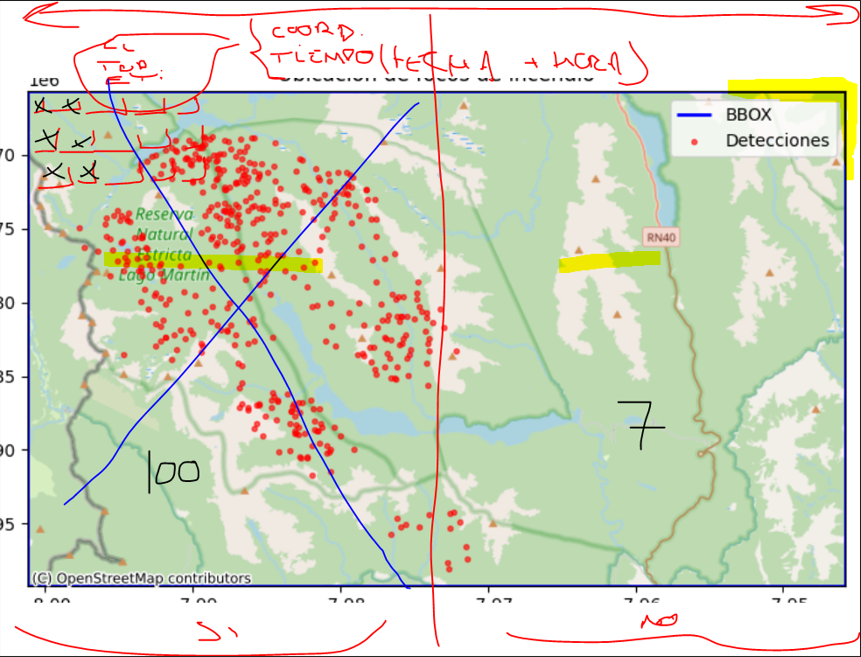

Esto implicaria perder el detalle que se obtiene desde VIIRS dado el traslado de sus datos de 375m a una escala de 25km, pero se aseguraria tener las variables climáticas que son el objeto de estudio para la predicción.


2. Llevar los datos meteorologícos a un grilla que se adapte a los focos de calor, está estrategía no mejoraría los datos de cara a la implementación de los modelos, dado que para cada foco, por ejemplo en la longitud oeste de la imagén de arriba, todos los focos tendrían las mismas condiciones climatologicas. Sin embargo, se podrían utilizar los métodos de interpolación y vecinos cercanos que expone Copernicus en su documentación.




### 3.2 - Unificación de conjuntos de datos.

In [ ]:
df_focos = pd.read_csv(f'{cfg.DATA_RAW}/firms/firms_VIIRS_SNPP_SP_2024-12-01_2025-03-31.csv')
df_clima = pd.read_csv(f"{cfg.DATA_RAW}/copernicus/land/land_2024-12-01_2025-03-31_20251004_184357.csv")

In [ ]:
df_clima['acq_datetime'] = pd.to_datetime(df_clima['acq_datetime'])
df_focos['acq_datetime'] = pd.to_datetime(
                df_focos['acq_date'] + ' ' + df_focos['acq_time'].astype(str).str.zfill(4),
                format = '%Y-%m-%d %H%M',
                errors = 'coerce'
            )

In [ ]:
print("Resolución espacial MODIS (0.1°) vs ERA5 (0.25°) \n")

print("Rango lat FIRMS:", df_focos['latitude'].min(), df_focos['latitude'].max())
print("Rango lon FIRMS:", df_focos['longitude'].min(), df_focos['longitude'].max())
print("Total coordenadas FIRMS:", df_focos['latitude'].nunique() * df_focos['longitude'].nunique(), "\n")

print("Rango lat ERA5:", df_clima['latitude'].min(), df_clima['latitude'].max())
print("Rango lon ERA5:", df_clima['longitude'].min(), df_clima['longitude'].max())
print("Total coordenadas ERA5:", df_clima['latitude'].nunique() * df_clima['longitude'].nunique(), "\n")

print("Rango tiempo FIRMS:", df_focos['acq_datetime'].min(), df_focos['acq_datetime'].max())
print("Rango tiempo ERA5:", df_clima['acq_datetime'].min(), df_clima['acq_datetime'].max())

FIRMS es mucho más fino (~375 m).

ERA5-LAND es más grueso (~9 km).


#### 3.2.1 - Asignación de coordenadas ERA5 a focos FIRMS.

In [ ]:
def assign_to_era5_cell(lat, lon, era5_lats, era5_lons):
    """Asigna coordenadas FIRMS a la celda ERA5 más cercana"""
    # Cálculo de la distancia absoluta entre las coordenadas FIRMS y las coordenadas ERA5.
    lat_dists = np.abs(era5_lats - lat)
    lon_dists = np.abs(era5_lons - lon)
    
    # Determinación de la latitud y longitud más cercanas.
    nearest_lat = era5_lats[np.argmin(lat_dists)]
    nearest_lon = era5_lons[np.argmin(lon_dists)]
    
    return nearest_lat, nearest_lon

def ec_assign_to_era5_cell(lat, lon, era5_lats, era5_lons) :
    """Asigna coordenadas FIRMS a la celda ERA5 más cercana usando distancia euclidiana"""
    # Crear malla de coordenadas ERA5, son las combinaciones de latitudes y longitudes.
    lat_grid, lon_grid = np.meshgrid(era5_lats, era5_lons, indexing = 'ij')
    
    # Distancia euclidiana entre las coordenadas FIRMS y todas las coordenadas ERA5.
    distances = np.sqrt((lat_grid - lat) ** 2 + (lon_grid - lon) ** 2)
    
    # Encontrar índice del mínimo, la celda más cercana en la grilla.
    min_idx = np.unravel_index(np.argmin(distances), distances.shape)
    
    return era5_lats[min_idx[0]], era5_lons[min_idx[1]]

In [ ]:
 # Redondeo de tiempos FIRMS a la resolución temporal utilizada en ERA5 (6 horas).
df_focos['acq_datetime'] = df_focos['acq_datetime'].dt.round('6h')

era5_lats = df_clima['latitude'].unique()
era5_lons = df_clima['longitude'].unique()
firms_era5_assigned = []

# Por cada registro de foco de incendio, se asigna el registro ERA5 más cercano en latitud y longitud.
for i in range(len(df_focos)):

    era5_lat, era5_lon = ec_assign_to_era5_cell(
        df_focos.iloc[i]['latitude'], 
        df_focos.iloc[i]['longitude'], 
        era5_lats, era5_lons)

    firms_era5_assigned.append({
        'acq_datetime': df_focos.iloc[i]['acq_datetime'],
        'era5_latitude': era5_lat,
        'era5_longitude': era5_lon,
        'n_fires': 1,
        'bright_ti4': df_focos.iloc[i]['bright_ti4'],
        'bright_ti5': df_focos.iloc[i]['bright_ti5'],
        'confidence': df_focos.iloc[i]['confidence'],
        'frp': df_focos.iloc[i]['frp'],
        'daynight': df_focos.iloc[i]['daynight'],
        'scan': df_focos.iloc[i]['scan'],
        'track': df_focos.iloc[i]['track'],
        'original_lat': df_focos.iloc[i]['latitude'],
        'original_lon': df_focos.iloc[i]['longitude']
    })

df_focos = pd.DataFrame(firms_era5_assigned)
# df_focos['acq_datetime'] = pd.to_datetime(df_focos['acq_datetime'])

print("Rango lat:", df_focos['era5_latitude'].min(), df_focos['era5_latitude'].max(), "| Cantidad:", df_focos['era5_latitude'].nunique())
print("Rango lon:", df_focos['era5_longitude'].min(), df_focos['era5_longitude'].max(), "| Cantidad:", df_focos['era5_longitude'].nunique())

# Agrupar incendios por fecha y coordenadas ERA5
df_focos = (
    df_focos.groupby(['acq_datetime', 'era5_latitude', 'era5_longitude'])
    .agg({
        'n_fires': 'sum',
        'original_lat': 'count',
        'bright_ti4': 'mean',
        'bright_ti5': 'mean',
        'frp': 'mean',
        'confidence': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'n',
        'scan': 'mean',
        'track': 'mean',
        'daynight': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'D'
    })
    .reset_index()
    .rename(columns={'original_lat': 'n_focos'})
)

# Opcional: Convertir confidence a valores numéricos para análisis de ML
confidence_map = {'l': 0.3, 'n': 0.6, 'h': 0.9}
df_focos['confidence_numeric'] = df_focos['confidence'].map(confidence_map)

df_focos.head(20)


 ##### Revisión:

In [ ]:
# Coordenadas asignadas existen en ERA5.
era5_coords = set(zip(df_clima['latitude'], df_clima['longitude']))
assigned_coords = set(zip(df_focos['era5_latitude'], df_focos['era5_longitude']))

print("Coordenas únicas en ERA5:", len(era5_coords))
print("Coordenas asignadas:", len(assigned_coords))
print("Todas las asignadas existen en ERA5:", assigned_coords.issubset(era5_coords))

In [ ]:
print("=== DISTRIBUCIÓN ESPACIAL ===")
print(f"Puntos FIRMS originales: {len(firms_era5_assigned)}")
print(f"Celdas ERA5 únicas con incendios: {df_focos['era5_latitude'].nunique()}")

# Distribución por coordenadas asignadas.
coord_counts = df_focos.groupby(['era5_latitude', 'era5_longitude']).size()
print("\nIncendios por celda ERA5:")
print(coord_counts.sort_values(ascending=False).head(10))

In [ ]:
# Celdas con muchos incendios (posible error de asignación)
high_fire_cells = df_focos[df_focos['n_focos'] > 10]
print(f"Celdas con más de 10 incendios: {len(high_fire_cells)}")

In [ ]:
# Test exhaustivo de la función de asignación
def test_assignment_function():
    test_points = [
        (-41.5, -71.7), (-41.4, -71.8), (-41.3, -71.9)  # Puntos en diferentes áreas
    ]
    
    for lat, lon in test_points:
        era5_lat, era5_lon = ec_assign_to_era5_cell(lat, lon, era5_lats, era5_lons)
        print(f"Test ({lat}, {lon}) -> ({era5_lat}, {era5_lon})")
        
        # Verificar que la asignación es razonable
        lat_diff = abs(lat - era5_lat)
        lon_diff = abs(lon - era5_lon)
        assert lat_diff <= 0.1, f"Error grande en latitud: {lat_diff}"
        assert lon_diff <= 0.1, f"Error grande en longitud: {lon_diff}"

test_assignment_function()

In [ ]:
# Distribución geográfica original
print("=== ANÁLISIS GEOGRÁFICO ORIGINAL ===")
original_lats = [point['original_lat'] for point in firms_era5_assigned]
original_lons = [point['original_lon'] for point in firms_era5_assigned]

print(f"Rango lat original: {min(original_lats):.3f} a {max(original_lats):.3f}")
print(f"Rango lon original: {min(original_lons):.3f} a {max(original_lons):.3f}")
print(f"Puntos únicos originales: {len(set(zip(original_lats, original_lons)))}")


#### 3.2.2 - Merge de conjuntos.

In [ ]:
# Merge con el dataset completo de ERA5
df = df_clima.merge(
    df_focos,
    left_on = ['acq_datetime', 'latitude', 'longitude'],
    right_on = ['acq_datetime', 'era5_latitude', 'era5_longitude'],
    how = 'left'
)

# Limpiar columnas
df = df.drop(columns = ['era5_latitude', 'era5_longitude'], errors = 'ignore')

print("Dataset final creado:")
print(f"Registros totales: {len(df)}")
df.head(10)

In [ ]:
df['latitude'] = df['latitude'].round(3)
df['longitude'] = df['longitude'].round(3)
df['month'] = df['acq_datetime'].dt.month
df['day'] = df['acq_datetime'].dt.day
df['hour'] = df['acq_datetime'].dt.hour

df = df.sort_values(['acq_datetime', 'latitude', 'longitude']).reset_index(drop = True)

# Guardar dataset
df.to_csv(f"{cfg.DATA_PROCESSED}/era5_with_fires_dataset_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv", index=False)
print(f"\nDataset guardado en: {cfg.DATA_PROCESSED}/era5_with_fires_dataset_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv")

In [ ]:
def exploratory_analysis(df):
    """Función para realizar análisis exploratorio completo con variables FIRMS"""
    print("=== ANÁLISIS EXPLORATORIO DEL DATASET ===")
    print(f"Total registros: {len(df)}")
    
    # Manejar nulos en variables de incendios para cálculos
    df_analysis = df.copy()
    fire_vars = ['n_fires', 'n_focos', 'bright_ti4', 'bright_ti5', 'frp']
    df_analysis[fire_vars] = df_analysis[fire_vars].fillna(0)
    
    # Crear variable has_fire para análisis
    df_analysis['has_fire'] = (df_analysis['n_fires'] > 0).astype(int)
    
    # Estadísticas básicas de incendios
    has_fire = df_analysis['has_fire'].sum()
    print(f"Registros con incendios: {has_fire} ({has_fire/len(df)*100:.2f}%)")
    
    if has_fire > 0:
        fire_data = df_analysis[df_analysis['n_fires'] > 0]
        print(f"FRP promedio en incendios: {fire_data['frp'].mean():.2f}")
        print(f"Brightness TI4 promedio: {fire_data['bright_ti4'].mean():.2f}K")
        print(f"Confianza más común: {fire_data['confidence'].mode().iloc[0]}")
    
    print(f"Variables disponibles: {list(df.columns)}")
    
    # Crear los gráficos
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
    # 1. Distribución de presencia de incendios
    df_analysis['has_fire'] = (df_analysis['n_fires'] > 0).astype(int)
    sns.countplot(x='has_fire', data=df_analysis, ax=axes[0,0])
    axes[0,0].set_title('Presencia/Ausencia de Incendios')
    axes[0,0].set_xticklabels(['Sin Incendio', 'Con Incendio'])
    
    # 2. Correlación con temperatura
    sns.boxplot(x='has_fire', y='t2m', data=df_analysis, ax=axes[0,1])
    axes[0,1].set_title('Temperatura vs Presencia de Incendios')
    axes[0,1].set_xticklabels(['Sin Incendio', 'Con Incendio'])
    
    # 3. Distribución de confianza
    if has_fire > 0:
        confidence_counts = fire_data['confidence'].value_counts()
        axes[0,2].pie(confidence_counts.values, labels=confidence_counts.index, autopct='%1.1f%%')
        axes[0,2].set_title('Distribución de Confianza en Incendios')
    else:
        axes[0,2].text(0.5, 0.5, 'No hay incendios', ha='center', va='center')
        axes[0,2].set_title('Distribución de Confianza')
    
    # 4. Serie temporal
    if 'date' not in df_analysis.columns:
        df_analysis['date'] = pd.to_datetime(df_analysis['acq_datetime']).dt.date
    daily_fires = df_analysis.groupby('date')['n_fires'].sum()
    axes[1,0].plot(daily_fires.index, daily_fires.values)
    axes[1,0].set_title('Evolución Temporal de Incendios')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # 5. Mapa de calor de correlaciones
    corr_vars = ['t2m', 'd2m', 'sp', 'u10', 'v10', 'tp', 'n_fires', 'frp', 'bright_ti4']
    available_corr_vars = [var for var in corr_vars if var in df_analysis.columns]
    correlation = df_analysis[available_corr_vars].corr()
    sns.heatmap(correlation, annot=True, ax=axes[1,1], cmap='coolwarm', center=0)
    axes[1,1].set_title('Matriz de Correlación')
    
    # 6. Distribución de FRP
    if has_fire > 0:
        axes[1,2].hist(fire_data['frp'], bins=20, alpha=0.7, color='red')
        axes[1,2].set_title('Distribución de FRP')
        axes[1,2].set_xlabel('FRP')
        axes[1,2].set_ylabel('Frecuencia')
    else:
        axes[1,2].text(0.5, 0.5, 'No hay incendios', ha='center', va='center')
        axes[1,2].set_title('Distribución de FRP')
    
    # 7. Distribución espacial de incendios
    # Separar datos con y sin incendios
    fire_coords = df_analysis[df_analysis['has_fire'] == 1]
    no_fire_coords = df_analysis[df_analysis['has_fire'] == 0]
    
    # Plot celdas sin incendios (gris claro, transparente)
    axes[2,0].scatter(no_fire_coords['longitude'], no_fire_coords['latitude'], 
                     c='lightgray', alpha=0.3, s=20, label='Sin incendios')
    
    # Plot celdas con incendios (colores según intensidad)
    if len(fire_coords) > 0:
        scatter = axes[2,0].scatter(fire_coords['longitude'], fire_coords['latitude'], 
                                  c=fire_coords['n_fires'], cmap='YlOrRd', alpha=0.8,
                                  s=50, label='Con incendios')
        plt.colorbar(scatter, ax=axes[2,0], label='Número de Incendios')
    
    axes[2,0].set_title('Distribución Espacial de Incendios')
    axes[2,0].set_xlabel('Longitud')
    axes[2,0].set_ylabel('Latitud')
    axes[2,0].legend()
    
    # 8. Intensidad de incendios (n_focos)
    if has_fire > 0:
        axes[2,1].hist(fire_data['n_focos'], bins=20, alpha=0.7, color='orange')
        axes[2,1].set_title('Distribución de Focos por Celda')
        axes[2,1].set_xlabel('Número de Focos')
        axes[2,1].set_ylabel('Frecuencia')
    else:
        axes[2,1].text(0.5, 0.5, 'No hay incendios', ha='center', va='center')
        axes[2,1].set_title('Distribución de Focos por Celda')
    
    # 9. Relación Brightness vs FRP
    if has_fire > 0:
        axes[2,2].scatter(fire_data['bright_ti4'], fire_data['frp'], alpha=0.6)
        axes[2,2].set_title('Brightness TI4 vs FRP')
        axes[2,2].set_xlabel('Brightness TI4 (K)')
        axes[2,2].set_ylabel('FRP')
    else:
        axes[2,2].text(0.5, 0.5, 'No hay incendios', ha='center', va='center')
        axes[2,2].set_title('Brightness TI4 vs FRP')
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas adicionales en consola
    if has_fire > 0:
        print("\n=== ESTADÍSTICAS DE INCENDIOS ===")
        print(f"Máximo focos por celda: {fire_data['n_focos'].max()}")
        print(f"FRP máximo: {fire_data['frp'].max():.2f}")
        print(f"Brightness TI4 máximo: {fire_data['bright_ti4'].max():.2f}K")
        print(f"Distribución día/noche: {fire_data['daynight'].value_counts().to_dict()}")

# Ejecutar análisis
exploratory_analysis(df)

In [ ]:
detection_map2(df)

In [ ]:
print("El total de incendios observados por FIRMS (MODIS) es de", df_focos['n_fires'].sum(), "focos. \n")
print("Focos en longitud -71.625:", df[df['longitude'] == -71.625]['n_focos'].sum())
print("Focos en longitud -71.876:", df[df['longitude'] == -71.876]['n_focos'].sum())
print("Focos en latitud -41.587:", df[df['latitude'] == -41.587]['n_focos'].sum())

In [ ]:
print("Total registros:", len(df))
print("Registros con fuego:", (df['n_fires'] > 0).sum())
print("Lat range:", df['latitude'].min(), df['latitude'].max())
print("Lon range:", df['longitude'].min(), df['longitude'].max())


In [ ]:
df[(df['n_fires'] > 0) & 
            (df['longitude'] == -71.80) &
            (df['latitude'] == -41.40)].iloc[:, np.r_[0:3, 19:29]].head(10)


### 3.3 - Ingenieria de variables


#### 3.3.1 - Fire Weather Index (FWI)

Caracteristicas del conjunto de datos:
- **d2m**: *Temperatura del punto de rocío a 2m* se calcula interpolando entre el nivel más bajo del modelo y la superficie terrestre, considerando las condiciones atmosféricas. Este parámetro se mide en kelvin (K). La temperatura medida en kelvin se puede convertir a grados Celsius (°C) restando 273,15.
  
- **t2m**: *Temperatura del aire a 2m* sobre la superficie terrestre, marina o de aguas continentales. Se calcula interpolando entre el nivel más bajo del modelo y la superficie terrestre, considerando las condiciones atmosféricas. La temperatura medida en kelvin se puede convertir a grados Celsius (°C) restando 273,15.
  
- **fal**: *Forecast albedo* es una medida de la reflectividad de la superficie terrestre. Es la fracción de radiación solar (de onda corta) reflejada por la superficie terrestre, a lo largo del espectro solar, tanto para la radiación directa como para la difusa.  Unidad de medida: Los valores oscilan entre 0 y 1.
  
- **slhf**: *Surface latent heat net flux (flujo neto de calor latente superficial)* representa la transferencia de calor latente (resultante de los cambios de fase del agua, como la evaporación o la condensación) entre la superficie terrestre y la atmósfera mediante el movimiento turbulento del aire. La evaporación de la superficie terrestre representa una transferencia de energía de la superficie a la atmósfera. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.
  
- **ssr**: *Surface net short-wave (solar) radiation* es la cantidad de radiación solar (también conocida como radiación de onda corta) que llega a un plano horizontal en la superficie de la Tierra (tanto directa como difusa) menos la cantidad reflejada por la superficie de la Tierra (que está gobernada por el albedo). Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **str**: *Surface net thermal radiation (Radiación térmica neta superficial)* es la radiación térmica (también conocida como radiación de onda larga o terrestre) y se refiere a la radiación emitida por la atmósfera, las nubes y la superficie terrestre. Este parámetro es la diferencia entre la radiación térmica descendente y ascendente en la superficie terrestre. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **sshf**: *Surface sensible heat net flux (flujo neto de calor sensible superficial)* representa la transferencia de calor entre la superficie terrestre y la atmósfera mediante el movimiento turbulento del aire (excluyendo la transferencia de calor resultante de la condensación o la evaporación). La magnitud del flujo de calor sensible se rige por la diferencia de temperatura entre la superficie y la atmósfera suprayacente, la velocidad del viento y la rugosidad de la superficie. Por ejemplo, el aire frío sobre una superficie cálida produciría un flujo de calor sensible desde la tierra (o el océano) hacia la atmósfera. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **ssrd**: *Surface short-wave (solar) radiation downwards (radiación superficial de onda corta (solar) hacia abajo)* es la cantidad de radiación solar (también conocida como radiación de onda corta) que alcanza un plano horizontal en la superficie terrestre. Este parámetro comprende tanto la radiación solar directa como la difusa. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **strd**: *Surface long-wave (thermal) radiation downwards (radiación superficial de onda larga (térmica) hacia abajo)* es la cantidad de radiación térmica (también conocida como de onda larga o terrestre) emitida por la atmósfera y las nubes que llega a un plano horizontal en la superficie de la Tierra. Unidad de medida: Julios por metro cuadrado (J m**-2). Para convertir a vatios por metro cuadrado (W m-2), los valores acumulados deben dividirse por el período de acumulación expresado en segundos.

- **e**: *Evaporation (evaporación)* es la cantidad acumulada de agua que se ha evaporado de la superficie de la Tierra, incluida una representación simplificada de la transpiración (de la vegetación), en vapor en el aire de arriba. Unidad de medida: m de agua equivalente.

- **u10**: *Componente de viento U de 10 metros* representa la componente este del viento de 10m. Es la velocidad horizontal del aire que se desplaza hacia el este, a una altura de diez metros sobre la superficie terrestre, en metros por segundo. Se debe tener cuidado al comparar este parámetro con las observaciones, ya que estas varían en escalas espaciales y temporales pequeñas y se ven afectadas por el terreno, la vegetación y los edificios locales, que solo se representan en promedio en el Sistema Integrado de Pronóstico del ECMWF. Este parámetro puede combinarse con la componente V del viento de 10m para obtener la velocidad y la dirección del viento horizontal de 10m. Unidad de medida: m/s.

- **v10**: *Componente de viento V de 10 metros* representa la componente norte del viento de 10m. Es la velocidad horizontal del aire que se desplaza hacia el norte, a una altura de diez metros sobre la superficie terrestre, en metros por segundo. Se debe tener cuidado al comparar este parámetro con las observaciones, ya que estas varían en escalas espaciales y temporales pequeñas y se ven afectadas por el terreno, la vegetación y los edificios locales, que solo se representan en promedio en el Sistema Integrado de Pronóstico del ECMWF. Este parámetro puede combinarse con la componente U del viento de 10m para obtener la velocidad y la dirección del viento horizontal de 10m. Unidad de medida: m/s.

- **sp**: *Presión superficial* representa la presión (fuerza por unidad de área) de la atmósfera sobre la superficie terrestre, marina y de aguas continentales. Es una medida del peso de todo el aire en una columna vertical sobre el área de la superficie terrestre representada en un punto fijo. La presión superficial se utiliza a menudo **en combinación con la temperatura para calcular la densidad del aire**. La fuerte variación de la presión con la altitud dificulta la visualización de los sistemas de baja y alta presión en zonas montañosas, por lo que se suele utilizar la presión media a nivel del mar, en lugar de la presión superficial, para este propósito. Unidad de medida: pascales (Pa), la presión superficial se suele medir en hPa y, a veces, se presenta en las antiguas unidades de milibares, mb (1 hPa = 1 mb = 100 Pa).

- **tp**: *Precipitación total* corresponde al agua líquida y congelada acumulada, compuesta por lluvia y nieve, que cae sobre la superficie terrestre. Es la suma de la precipitación a gran escala y la precipitación convectiva. Representa la cantidad total de agua acumulada durante un período determinado, que depende de los datos extraídos. Unidad de medida: metros.

- **lai_hv**: *Índice de área foliar, vegetación alta* representa la superficie de un lado de todas las hojas presentes en un área de terreno para la vegetación clasificada como "alta". Este parámetro tiene un valor de 0 en terrenos desnudos o donde no hay hojas. La "vegetación alta" incluye árboles de hoja perenne, árboles de hoja caduca, bosques mixtos y bosques interrumpidos. Unidad de medida: m^2.

- **lai_lv**: *Índice de área foliar, vegetación baja* representa la superficie de un lado de todas las hojas presentes en un área de terreno para la vegetación clasificada como "baja". Este parámetro tiene un valor de 0 en terrenos desnudos o sin hojas. La "vegetación baja" incluye cultivos y agricultura mixta, cultivos de regadío, pastos cortos, pastos altos, tundra, semidesiertos, turberas y marismas, arbustos perennes, arbustos caducifolios y mezclas de agua y tierra. Unidad de medida: m^2.

In [ ]:
def kelvin_a_celsius(value) :
    """
    Convierte una temperatura de Kelvin a Celsius. 
    
    Parámetros:
    value: Temperatura en Kelvin.

    Retorna:
    Temperatura en Celsius.
    """
    celsius = value - 273.15
    return celsius

def conversion_kelvin(df) :
    """
    Convierte las columnas de temperatura de Kelvin a Celsius en un DataFrame.
    
    Parámetros:
    df: DataFrame con columnas 't2m' y 'd2m' en Kelvin.

    Retorna:
    DataFrame con las columnas 't2m' y 'd2m' convertidas a Celsius.
    """
    kelvin_cols = ['t2m', 'd2m']
    for col in kelvin_cols :
        df[col] = df[col].apply(kelvin_a_celsius)
    return df

def humedad_relativa(temperature, dew_point) :
    """
    Calcula la humedad relativa a partir de la temperatura y el punto de rocío.
    
    Parámetros:
    temperature: Temperatura en grados Celsius.
    dew_point: Punto de rocío en grados Celsius.
    
    Retorna:
    Humedad relativa en porcentaje.
    """
    rh = 100 * (np.exp((17.625 * dew_point) / (243.04 + dew_point)) / np.exp((17.625 * temperature) / (243.04 + temperature)))
    return rh

# Calculo de la velocidad y dirección del viento a partir de componentes u y v.
def viento_vel_dir(u, v) :
    """
    Calcula la velocidad y dirección del viento a partir de componentes u y v.
    
    Parámetros:
    u (ERA5 notation: u-component of wind): componente zonal del viento (m/s).
    v (ERA5 notation: v-component of wind): componente meridional del viento (m/s).

    Retorna:
    vel: velocidad del viento (m/s).
    dir: dirección del viento (grados desde el norte).
    """
    vel = np.sqrt(u ** 2 + v ** 2) # Teorema de Pitágoras.
    dir = (np.arctan2(v, u) * (180 / np.pi) + 360) % 360 # Función arcotangente en grados.
    return vel, dir

# Precipitación acumulada a precipitación por intervalo en mm.
def calcular_precipitacion(group):
    """
    Calcula la precipitación por intervalo a partir de la precipitación acumulada.
    
    Parámetros:
    group : Grupo de datos con columna 'tp_mm' (precipitación acumulada en mm)
    
    Retorna:
    Serie con precipitación por intervalo
    """
    tp_mm = group['tp_mm']
    diferencia = tp_mm.diff()
    
    # Primera observación: usar el valor acumulado como primer intervalo
    diferencia.iloc[0] = tp_mm.iloc[0]
    
    # Si hay reinicio de acumulación (diferencia < 0), usar el valor actual
    diferencia_negativa = diferencia < 0
    if diferencia_negativa.any():
        diferencia.loc[diferencia_negativa] = tp_mm.loc[diferencia_negativa]
    
    # Asegurar que no hay valores negativos
    diferencia = diferencia.clip(lower = 0.0)
    
    return diferencia

def aplicar_precipitacion(df, columna_acumulada = 'tp'):
    """
    Función que dado un DataFrame con precipitación acumulada en metros,
    calcula la precipitación por intervalo en mm y la añade como nueva columna.

    Parámetros:
    df : DataFrame con columnas 'latitude', 'longitude', 'time' y columna de precipitación acumulada (por defecto 'tp').
    columna_acumulada : Nombre de la columna con precipitación acumulada en metros (default='tp').

    Retorna:
    df : DataFrame con nueva columna 'precipitacion_mm' con precipitación por intervalo
    """
    df = df.copy()
    
    df['tp_mm'] = df[columna_acumulada] * 1000
    
    precip_results = []

    for (lat, lon), group in df.groupby(['latitude', 'longitude']):
        # Aplicar solo a las filas del grupo, no a las columnas de agrupación
        precip_grupo = calcular_precipitacion(group)
        precip_results.append(precip_grupo)

    df['precipitacion_mm'] = pd.concat(precip_results)
    
    return df

# FFMC (Fine Fuel Moisture Code).
def calcular_ffmc(temperature, rh, wind_speed, precipitation, previous_ffmc = 85.0) :
    """
    Calcula el Fine Fuel Moisture Code (FFMC) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    temperature : Temperatura en °C
    rh : Humedad relativa en %
    wind_speed : Velocidad del viento en m/s (se convierte a km/h)
    precipitation : Precipitación en mm
    previous_ffmc : FFMC del día anterior (default=85.0)
    
    Retorna:
    ffmc : Fine Fuel Moisture Code

    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Fine+fuel+moisture+code
    """
    if any(pd.isna([temperature, rh, wind_speed, precipitation])):
        return previous_ffmc

    wind_speed_kmh = wind_speed * 3.6

    m0 = 147.2 * (101 - previous_ffmc) / (59.5 + previous_ffmc)
    
    # Efecto de la lluvia.
    if precipitation > 0.5 :
        rf = precipitation - 0.5
        if m0 > 150:
            m0 = m0 + 42.5 * rf * np.exp(-100 / (251 - m0)) * (1 - np.exp(-6.93 / rf))
        else:
            m0 = m0 + 42.5 * rf * np.exp(-100 / (251 - m0)) * (1 - np.exp(-6.93 / rf))
            if m0 > 150:
                m0 = 150 + (m0 - 150) / 1.0
    
    m0 = max(m0, 0)
    
    # Efecto de la temperatura y humedad
    Ed = 0.942 * (rh ** 0.679) + (11 * np.exp((rh - 100) / 10)) + 0.18 * (21.1 - temperature) * (1 - np.exp(-0.115 * rh))
    
    if m0 > Ed:
        Ew = 0.618 * (rh ** 0.753) + (10 * np.exp((rh - 100) / 10)) + 0.18 * (21.1 - temperature) * (1 - np.exp(-0.115 * rh))
        if m0 < Ew:
            k0 = 0.424 * (1 - ((100 - rh) / 100) ** 1.7) + 0.0694 * (wind_speed ** 0.5) * (1 - ((100 - rh) / 100) ** 8)
            m = Ew - (Ew - m0) * (10 ** (-k0))
        else:
            m = m0
    else:
        k0 = 0.424 * (1 - (rh / 100) ** 1.7) + 0.0694 * (wind_speed ** 0.5) * (1 - (rh / 100) ** 8)
        m = Ed + (m0 - Ed) * (10 ** (-k0))
    
    ffmc = 59.5 * (250 - m) / (147.2 + m)
    ffmc = max(0, min(ffmc, 101))
    return ffmc

def calcular_ffmc_series(df, ffmc0 = 85.0) :
    """
    Calcula FFMC como serie recursiva a partir de columnas completas.

    Parámetros:
    temperature : Serie de temperaturas en °C
    rh : Serie de humedad relativa en %
    wind_speed : Serie de velocidades del viento en m/s
    precipitation : Serie de precipitaciones en mm
    ffmc0 : FFMC inicial (default=85.0)

    Retorna:
    ffmc_values : Lista de valores FFMC calculados
    """

    ffmc_values = [ffmc0]
    for i in range(1, len(df)):
        ffmc = calcular_ffmc(
            df['t2m'].iloc[i], 
            df['humedad_relativa'].iloc[i],
            df['wind_speed'].iloc[i], 
            df['precipitacion_mm'].iloc[i],
            ffmc_values[-1]
        )
        ffmc_values.append(ffmc)
    return ffmc_values

# 6. DMC (Duff Moisture Code).
def calcular_dmc(temperature, rh, precipitation, previous_dmc = 6.0, month = 12) :
    """
    Calcula el Duff Moisture Code (DMC) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    temperature : Temperatura en °C
    rh : Humedad relativa en %
    precipitation : Precipitación en mm
    previous_dmc : DMC del día anterior (default=6.0)
    month : Mes del año (1-12) para ajuste estacional (default=7)
    
    Retorna:
    dmc : Duff Moisture Code

    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Duff+moisture+code
    """
    
    # Factores de longitud del día para hemisferio sur (horas de luz)
    day_length_factors = np.array([
        14.5,   # Enero  (14h 30m)
        13.92,  # Febrero (13h 55m)
        12.92,  # Marzo (12h 55m)
        11.92,  # Abril (11h 55m)
        10.50,  # Mayo (10h 30m)
        9.30,   # Junio (9h 18m aprox.)
        9.50,   # Julio (9h 30m)
        10.58,  # Agosto (10h 35m)
        11.92,  # Septiembre (11h 55m)
        13.02,  # Octubre (13h 01m)
        14.03,  # Noviembre (14h 02m)
        15.08   # Diciembre (15h 05m)
    ])
    
    # Obtener factor de ajuste del mes (0-indexed)
    day_length_adjustment = day_length_factors[month - 1]
    
    # Efecto de la lluvia
    dmc = previous_dmc
    
    if precipitation > 1.5:
        # Calcular contenido de humedad equivalente
        re = 0.92 * precipitation - 1.27
        # Contenido de humedad del duff
        mo = 20 + np.exp(5.6348 - dmc / 43.43)
        
        if dmc <= 33:
            b = 100 / (0.5 + 0.3 * dmc)
        elif dmc <= 65:
            b = 14 - 1.3 * np.log(dmc)
        else:
            b = 6.2 * np.log(dmc) - 17.2
        
        # Pérdida por lluvia
        mr = mo + 1000 * re / (48.77 + b * re)
        
        # Nuevo DMC después de la lluvia
        dmc = 244.72 - 43.43 * np.log(mr - 20)
        
        if dmc < 0:
            dmc = 0
    
    # Efecto de la temperatura y humedad
    if temperature < -1.1:
        temperature = -1.1
    
    # Déficit de saturación
    k = 1.894 * (temperature + 1.1) * (100 - rh) * day_length_adjustment * 1e-4
    
    # Aplicar cambio por temperatura/humedad
    dmc += k
    
    # Asegurar que DMC no sea negativo
    dmc = max(dmc, 0)
    
    return dmc

def calcular_dmc_series(temperature, rh, precipitation, initial_dmc = 6.0, month_series = None) :
    """
    Versión vectorizada para cálculo de DMC en series temporales.
    
    Parámetros:
    temperature: Serie de temperaturas en °C
    rh: Serie de humedad relativa en %
    precipitation: Serie de precipitación en mm
    initial_dmc: DMC inicial (default=6.0)
    month_series: Serie de meses (1-12), si es None se infiere de las fechas

    Retorna:
    dmc_values : Lista de valores DMC calculados

    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Duff+moisture+code
    """
    dmc_values = []
    dmc_prev = initial_dmc
    
    for i in range(len(temperature)):
        # Usar la serie de meses proporcionada o valor por defecto
        if month_series is None:
            month = 12
        else:
            month = month_series.iloc[i]

        dmc = calcular_dmc(
            temperature = temperature.iloc[i],
            rh = rh.iloc[i],
            precipitation = precipitation.iloc[i],
            previous_dmc = dmc_prev,
            month = month
        )
        dmc_values.append(dmc)
        dmc_prev = dmc
    
    return dmc_values

# DC (Drought Code).
def calcular_dc(temperature, precipitation, previous_dc = 15.0, month = 12, lat = None):
    """
    Calcula el Drought Code (DC) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    temperature : Temperatura en °C
    precipitation : Precipitación en mm
    previous_dc : DC del día anterior (default = 15.0)
    month : Mes del año (1-12) para ajuste estacional (default = 12)
    lat : Latitud en grados (opcional, para consistencia con DMC)
    
    Retorna:
    dc : Drought Code

    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Drought+code
    """
    
    # Factores de longitud del día para hemisferio sur (mismos que DMC)
    day_length_factors = np.array([
        14.5,   # Enero  (14h 30m)
        13.92,  # Febrero (13h 55m)
        12.92,  # Marzo (12h 55m)
        11.92,  # Abril (11h 55m)
        10.50,  # Mayo (10h 30m)
        9.30,   # Junio (9h 18m aprox.)
        9.50,   # Julio (9h 30m)
        10.58,  # Agosto (10h 35m)
        11.92,  # Septiembre (11h 55m)
        13.02,  # Octubre (13h 01m)
        14.03,  # Noviembre (14h 02m)
        15.08   # Diciembre (15h 05m)
    ])
    
    # Obtener factor de ajuste del mes (0-indexed)
    day_length_adjustment = day_length_factors[month - 1]
    
    # Paso 1: Efecto de la lluvia
    dc = previous_dc
    
    if precipitation > 2.8:
        # Reducción por lluvia
        rd = 0.83 * precipitation - 1.27
        # Contenido de humedad equivalente
        qo = 800 * np.exp(-dc / 400)
        # Nuevo contenido de humedad después de lluvia
        qr = qo + 3.937 * rd
        # Nuevo DC después de lluvia
        dc = 400 * np.log(800 / qr) if qr > 0 else 0
        
        if dc < 0:
            dc = 0
    
    # Paso 2: Efecto de la temperatura (drying)
    if temperature < -2.8:
        temperature = -2.8
    
    # Pérdida por temperatura
    v = 0.36 * (temperature + 2.8) + day_length_adjustment / 2
    v = max(v, 0)  # No permitir valores negativos
    
    # Aplicar pérdida por temperatura
    dc += v
    
    # Asegurar que DC no sea negativo
    dc = max(dc, 0)
    
    return dc

def calcular_dc_series(temperature, precipitation, initial_dc = 15.0, month_series = None) :
    """
    Versión vectorizada para cálculo de DC en series temporales.
    
    Parámetros:
    temperature : Serie de temperaturas en °C
    precipitation : Serie de precipitación en mm
    initial_dc : DC inicial (default=15.0)
    month_series : Serie de meses (1-12), si es None se infiere de las fechas
    
    Retorna:
    dc_values : Lista de valores DC calculados

    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Drought+code
    """
    dc_values = []
    dc_prev = initial_dc
    
    for i in range(len(temperature)):
        # Usar la serie de meses proporcionada o valor por defecto
        if month_series is None:
            month = 12  # Valor por defecto (Diciembre)
        else:
            month = month_series.iloc[i]
        
        dc = calcular_dc(
            temperature = temperature.iloc[i],
            precipitation = precipitation.iloc[i],
            previous_dc = dc_prev,
            month = month
        )
        dc_values.append(dc)
        dc_prev = dc
    
    return dc_values

# ISI (Initial Spread Index)
def calcular_isi(ffmc, wind_speed):
    """
    Calcula el Initial Spread Index (ISI) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    ffmc : Fine Fuel Moisture Code
    wind_speed : Velocidad del viento en km/h
    
    Retorna:
    isi : Initial Spread Index
    
    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Initial+spread+index
    """
    # Convertir viento de m/s a km/h si es necesario
    wind_speed_kmh = wind_speed * 3.6
    
    # Moisture content
    m = 147.2 * (101 - ffmc) / (59.5 + ffmc)
    
    # FFMC effect
    fF = 91.9 * np.exp(-0.1386 * m) * (1 + (m**5.31) / 49300000)
    
    # Wind effect
    fW = np.exp(0.05039 * wind_speed_kmh)
    
    # ISI
    isi = 0.208 * fW * fF
    
    return isi

# BUI (Build Up Index)
def calcular_bui(dmc, dc):
    """
    Calcula el Build Up Index (BUI) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    dmc : Duff Moisture Code
    dc : Drought Code
    
    Retorna:
    bui : Build Up Index
    
    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Build-up+index
    """
    if dmc <= 0.4 * dc:
        bui = (0.8 * dc * dmc) / (dmc + 0.4 * dc)
    else:
        bui = dmc - (1 - 0.8 * dc / (dmc + 0.4 * dc)) * (0.92 + (0.0114 * dmc) ** 1.7)
    
    bui = max(bui, 0)
    return bui

# FWI (Fire Weather Index)
def calcular_fwi(isi, bui):
    """
    Calcula el Fire Weather Index (FWI) del Canadian Forest Fire Weather Index System.
    
    Parámetros:
    isi : Initial Spread Index
    bui : Build Up Index
    
    Retorna:
    fwi : Fire Weather Index
    
    Ver: https://wikifire.wsl.ch/tiki-index91f7.html?page=Fire+weather+index
    """
    if bui <= 80:
        fD = 0.626 * (bui ** 0.809) + 2
    else:
        fD = 1000 / (25 + 108.64 * np.exp(-0.023 * bui))
    
    B = 0.1 * isi * fD
    if B <= 1:
        fwi = B
    else:
        fwi = np.exp(2.72 * (0.434 * np.log(B)) ** 0.647)
    
    return fwi

# Clasificación de riesgo
def clasificar_riesgo_fwi(fwi):
    """Clasifica el riesgo de incendio basado en FWI"""
    if fwi < 5:
        return "Muy Bajo"
    elif fwi < 10:
        return "Bajo"
    elif fwi < 20:
        return "Moderado"
    elif fwi < 30:
        return "Alto"
    elif fwi < 50:
        return "Muy Alto"
    else:
        return "Extremo"

def calcular_fwi_completo(df) :
    """Función que calcula el FWI completo y sus componentes, añadiéndolos al DataFrame."""
    df = conversion_kelvin(df.copy())    
    
    df['humedad_relativa'] = humedad_relativa(df['t2m'], df['d2m'])
    df['wind_speed'], df['wind_direction'] = viento_vel_dir(df['u10'], df['v10'])
    df = aplicar_precipitacion(df)    
    
    df['ffmc'] = calcular_ffmc_series(df)
    df['dmc'] = calcular_dmc_series(df['t2m'], df['humedad_relativa'], df['precipitacion_mm'], month_series = df['month'])
    df['dc'] = calcular_dc_series(df['t2m'], df['precipitacion_mm'], month_series = df['month'])
    df['isi'] = df.apply(
        lambda x : calcular_isi(x['ffmc'], x['wind_speed']), 
        axis = 1
    )    
    df['bui'] = df.apply(
        lambda x : calcular_bui(x['dmc'], x['dc']), 
        axis = 1
    )    
    df['fwi'] = df.apply(
        lambda x : calcular_fwi(x['isi'], x['bui']), 
        axis = 1
    )
    df['riesgo_incendio'] = df['fwi'].apply(clasificar_riesgo_fwi)
    
    return df

In [122]:
# -------------------------
# Conversión y utilidades
# -------------------------
def kelvin_a_celsius(value):
    """
    Convierte Kelvin a Celsius. Acepta escala (serie/array/escala).
    """
    return value - 273.15

def conversion_kelvin(df, cols = ['t2m', 'd2m']):
    """
    Convierte columnas de Kelvin a Celsius de forma vectorizada.
    Modifica una copia del DataFrame y devuelve la copia.
    """
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype('float64') - 273.15
    return df

def humedad_relativa(temperature, dew_point):
    """
    Calcula humedad relativa usando la aproximación de Magnus.
    Acepta scalars, numpy arrays o pandas Series.
    Retorna misma estructura (numpy array o pandas Series) que la entrada temperature.
    """
    # asegurarse tipo numpy para operaciones vectorizadas
    # formula: RH = 100 * (exp(a*Td/(b+Td)) / exp(a*T/(b+T)))
    a = 17.625
    b = 243.04
    num = np.exp((a * dew_point) / (b + dew_point))
    den = np.exp((a * temperature) / (b + temperature))
    rh = 100.0 * (num / den)
    # limitar en [0,100]
    rh = np.clip(rh, 0.0, 100.0)
    return rh

def viento_vel_dir(u, v):
    """
    Devuelve (velocidad_m_s, direccion_grados_desde_norte).
    Acepta scalars, arrays o pandas Series. Dirección en grados [0,360),
    medida desde el norte (0° = norte) siguiendo convención meteorológica
    (si se quiere conversión distinta, ajustarla).
    """
    # velocidad en m/s
    vel = np.sqrt(np.asarray(u) ** 2 + np.asarray(v) ** 2)
    # atan2 devuelve radianes; convertir a grados y ajustar para que 0=Este normalmente,
    # pero dejamos la dirección como el ángulo estándar arctan2(y,x) ajustado a [0,360)
    # Si se desea "grados desde el norte" con convención meteorológica, hay que transformar.
    # Aquí mantenemos: dir = (atan2(v,u) en grados + 360) % 360
    dir_deg = (np.degrees(np.arctan2(np.asarray(v), np.asarray(u))) + 360) % 360
    return vel, dir_deg

# -------------------------
# Precipitación
# -------------------------
def calcular_precipitacion(group, tp_col='tp_mm', time_col='acq_datetime'):
    """
    Dado un grupo (DataFrame) correspondiente a un punto espacial ordenado
    por tiempo, calcula la precipitación por intervalo a partir de acumulada (tp_mm).
    Devuelve una Series index-alineada con group.index con la precipitación por intervalo (mm).
    Reglas:
      - first interval = valor acumulado en esa primera fila
      - si diff < 0 (reinicio del acumulado), usar valor actual del acumulado
      - clip a >= 0
    """
    tp = group[tp_col].astype('float64')
    # asegurar orden temporal. Si ya está ordenado, no modifica.
    if time_col in group.columns:
        tp = tp.sort_index() if False else tp  # placeholder (ordenamiento hecho por caller)
    diff = tp.diff()
    # primer valor = acumulado
    diff.iloc[0] = tp.iloc[0]
    # si hay reinicio (diff < 0) usar valor actual del acumulado
    mask_neg = diff < 0
    if mask_neg.any():
        diff.loc[mask_neg] = tp.loc[mask_neg]
    # evitar negativos
    diff = diff.clip(lower=0.0)
    return diff

def aplicar_precipitacion(df, columna_acumulada='tp', tp_mm_col='tp_mm', out_col='precipitacion_mm',
                          group_cols = ['latitude','longitude'], time_col='acq_datetime'):
    """
    Calcula precipitación por intervalo en mm agrupando por punto espacial.
    - columna_acumulada: nombre original en metros (ej 'tp')
    - crea columna tp_mm = columna_acumulada * 1000
    - crea columna out_col (precipitación por intervalo en mm), alineada al df original
    """
    df = df.copy()
    # 1) convertir m -> mm
    if columna_acumulada not in df.columns:
        raise KeyError(f"columna acumulada '{columna_acumulada}' no encontrada en df")
    df[tp_mm_col] = df[columna_acumulada].astype('float64') * 1000.0

    # asegurar columna de tiempo tipo datetime
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])

    # Resultado vacio con mismo índice
    resultado = pd.Series(index=df.index, dtype='float64')

    # Agrupar por lat/lon (mantener orden temporal dentro de cada grupo)
    groupby_obj = df.groupby(group_cols, sort=False)
    for _, group_idx in groupby_obj.groups.items():
        group = df.loc[group_idx].sort_values(time_col)
        precip_interval = calcular_precipitacion(group, tp_col=tp_mm_col, time_col=time_col)
        # Asignar respetando índices originales
        resultado.loc[precip_interval.index] = precip_interval

    # Añadir columna al DataFrame (llenará NaN donde no hubo grupo)
    df[out_col] = resultado
    # Si algún NaN (puntos sin tp), rellenar con 0
    df[out_col] = df[out_col].fillna(0.0)
    return df

# -------------------------
# FFMC (serie por punto espacial)
# -------------------------
# def calcular_ffmc(temperature, rh, wind_speed, precipitation, previous_ffmc = 85.0):
#     """
#     Mantengo la implementación original de la fórmula por observación.
#     temperature: °C
#     rh: %
#     wind_speed: m/s
#     precipitation: mm (interval)
#     previous_ffmc: valor previo (0-101)
#     """
#     # manejar nans: si falta información devolvemos previous_ffmc
#     if any(pd.isna([temperature, rh, wind_speed, precipitation])):
#         return previous_ffmc

#     # wind_speed_kmh = wind_speed * 3.6
#     m0 = 147.2 * (101.0 - previous_ffmc) / (59.5 + previous_ffmc)

#     # efecto lluvia
#     if precipitation > 0.5:
#         rf = precipitation - 0.5
#         # la fórmula aplicada es la misma para ambos casos; se preserva el tope
#         m0 = m0 + 42.5 * rf * np.exp(-100.0 / (251.0 - m0)) * (1.0 - np.exp(-6.93 / rf))
#         if m0 > 150.0:
#             # tope parecido al original
#             m0 = 150.0 + (m0 - 150.0) / 1.0

#     m0 = max(m0, 0.0)

#     Ed = 0.942 * (rh ** 0.679) + (11.0 * np.exp((rh - 100.0) / 10.0)) + 0.18 * (21.1 - temperature) * (1.0 - np.exp(-0.115 * rh))

#     if m0 > Ed :
#         Ew = 0.618 * (rh ** 0.753) + (10.0 * np.exp((rh - 100.0) / 10.0)) + 0.18 * (21.1 - temperature) * (1.0 - np.exp(-0.115 * rh))
#         if m0 < Ew:
#             wind_speed = wind_speed * 3.6
#             k0 = 0.424 * (1.0 - ((100.0 - rh) / 100.0) ** 1.7) + 0.0694 * (wind_speed ** 0.5) * (1.0 - ((100.0 - rh) / 100.0) ** 8)
#             m = Ew - (Ew - m0) * (10.0 ** (-k0))
#         else :
#             m = m0
#     else :
#         wind_speed = wind_speed * 3.6
#         k0 = 0.424 * (1.0 - (rh / 100.0) ** 1.7) + 0.0694 * (wind_speed ** 0.5) * (1.0 - (rh / 100.0) ** 8)
#         m = Ed + (m0 - Ed) * (10.0 ** (-k0))

#     ffmc = 59.5 * (250.0 - m) / (147.2 + m)
#     ffmc = float(np.clip(ffmc, 0.0, 101.0))
#     return ffmc

def calcular_ffmc(temperature, rh, wind_speed, precipitation, previous_ffmc=85.0):
    """
    Versión CORREGIDA y validada de la función para calcular FFMC.
    Asegura el uso correcto de la velocidad del viento en km/h.
    
    Args:
        temperature (float): Temperatura en °C.
        rh (float): Humedad relativa en %.
        wind_speed (float): Velocidad del viento en m/s.
        precipitation (float): Precipitación en mm.
        previous_ffmc (float): FFMC del día anterior.
    """
    if any(pd.isna([temperature, rh, wind_speed, precipitation])):
        return previous_ffmc

    # --- 1. PREPARACIÓN ---
    # Convertir viento de m/s a km/h UNA SOLA VEZ al principio.
    wind_speed_kmh = wind_speed * 3.6
    
    # Contenido de humedad del combustible fino del día anterior (m0)
    m0 = 147.2 * (101.0 - previous_ffmc) / (59.5 + previous_ffmc)

    # --- 2. EFECTO DE LA LLUVIA ---
    if precipitation > 0.5:
        rf = precipitation - 0.5
        # La fórmula de lluvia es compleja, nos basamos en la original del sistema
        if m0 <= 150.0:
            m0 += 42.5 * rf * np.exp(-100.0 / (251.0 - m0)) * (1.0 - np.exp(-6.93 / rf))
        # El contenido de humedad no puede exceder 150
        m0 = min(m0, 150.0)

    # --- 3. EFECTO DEL SECADO (TEMPERATURA, HUMEDAD, VIENTO) ---
    # Humedad de equilibrio por secado (Ed) y por humectación (Ew)
    Ed = 0.942 * (rh**0.679) + 11.0 * np.exp((rh - 100.0) / 10.0) + \
         0.18 * (21.1 - temperature) * (1.0 - np.exp(-0.115 * rh))
    
    Ew = 0.618 * (rh**0.753) + 10.0 * np.exp((rh - 100.0) / 10.0) + \
         0.18 * (21.1 - temperature) * (1.0 - np.exp(-0.115 * rh))

    # Lógica principal de secado/humectación
    if m0 > Ed:
        # Secado
        k0 = 0.424 * (1.0 - (rh / 100.0)**1.7) + \
             0.0694 * np.sqrt(wind_speed_kmh) * (1.0 - (rh / 100.0)**8) # <-- USO CORRECTO
        kd = k0 * 0.581 * np.exp(0.0365 * temperature)
        m = Ed + (m0 - Ed) / (10.0**kd)
    elif m0 < Ew:
        # Humectación
        k1 = 0.424 * (1.0 - ((100.0 - rh) / 100.0)**1.7) + \
             0.0694 * np.sqrt(wind_speed_kmh) * (1.0 - ((100.0 - rh) / 100.0)**8) # <-- USO CORRECTO
        kw = k1 * 0.581 * np.exp(0.0365 * temperature)
        m = Ew - (Ew - m0) / (10.0**kw)
    else:
        m = m0

    # --- 4. CÁLCULO FINAL DEL FFMC ---
    ffmc = (59.5 * (250.0 - m)) / (147.2 + m)
    
    return np.clip(ffmc, 0.0, 101.0)


def calcular_ffmc_series(df, ffmc0 = 85.0, group_cols = ['latitude','longitude'],
                         time_col='acq_datetime', temp_col='t2m', rh_col='humedad_relativa',
                         wind_col='wind_speed', precip_col='precipitacion_mm'):
    """
    Calcula FFMC por punto espacial (group_cols), preservando la secuencia temporal.
    Devuelve una pandas.Series alineada con df.index.
    """
    # Preparar serie de resultados
    ffmc_result = pd.Series(index=df.index, dtype='float64')

    # Asegurar columna de tiempo y orden por grupo
    df = df.copy()
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])

    grouped = df.groupby(group_cols, sort=False)
    for key, group_idx in grouped.groups.items():
        group = df.loc[group_idx].sort_values(time_col)
        prev = ffmc0
        vals = []
        for i, row in group.iterrows():
            prev = calcular_ffmc(
                temperature = row[temp_col],
                rh = row[rh_col],
                wind_speed = row[wind_col],
                precipitation = row[precip_col],
                previous_ffmc = prev
            )
            vals.append(prev)
        ffmc_result.loc[group.index] = vals
    ffmc_result = ffmc_result.fillna(ffmc0)
    return ffmc_result

# -------------------------
# DMC (serie por punto espacial)
# -------------------------
def calcular_dmc(temperature, rh, precipitation, previous_dmc = 6.0, month = 12):
    """
    Implementación por observación (versión corregida y clarificada).
    temperature: °C
    rh: %
    precipitation: mm (interval)
    """
    # Factores de longitud del día para hemisferio sur (horas de luz aproximadas)
    day_length_factors = np.array([
        14.5, 13.92, 12.92, 11.92, 10.50, 9.30,
        9.50, 10.58, 11.92, 13.02, 14.03, 15.08
    ])
    day_length_adjustment = day_length_factors[int(month) - 1]

    dmc = previous_dmc

    # lluvia
    if precipitation > 1.5:
        re = 0.92 * precipitation - 1.27
        mo = 20.0 + np.exp(5.6348 - dmc / 43.43)
        if dmc <= 33.0:
            b = 100.0 / (0.5 + 0.3 * dmc)
        elif dmc <= 65.0:
            b = 14.0 - 1.3 * np.log(dmc)
        else:
            b = 6.2 * np.log(dmc) - 17.2
        mr = mo + 1000.0 * re / (48.77 + b * re)
        dmc = 244.72 - 43.43 * np.log(mr - 20.0)
        dmc = max(dmc, 0.0)

    # temperatura minima
    temp_adj = max(temperature, -1.1)
    k = 1.894 * (temp_adj + 1.1) * (100.0 - rh) * day_length_adjustment * 1e-4
    dmc = dmc + k
    dmc = max(dmc, 0.0)
    return dmc

def calcular_dmc_series(df, initial_dmc = 6.0, group_cols = ['latitude','longitude'],
                        time_col='acq_datetime', temp_col='t2m', rh_col='humedad_relativa',
                        precip_col='precipitacion_mm', month_col = None):
    """
    Calcula DMC por punto espacial.
    - month_col: nombre de la columna con el mes (1..12). Si None, se infiere desde time_col.
    """
    df = df.copy()
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
    if month_col is None and time_col in df.columns:
        df['__month_inferred__'] = df[time_col].dt.month
        month_col = '__month_inferred__'

    dmc_result = pd.Series(index=df.index, dtype='float64')

    grouped = df.groupby(group_cols, sort=False)
    for key, group_idx in grouped.groups.items():
        group = df.loc[group_idx].sort_values(time_col)
        prev = initial_dmc
        vals = []
        for i, row in group.iterrows():
            month = int(row[month_col]) if month_col in row.index else 12
            prev = calcular_dmc(
                temperature = row[temp_col],
                rh = row[rh_col],
                precipitation = row[precip_col],
                previous_dmc = prev,
                month = month
            )
            vals.append(prev)
        dmc_result.loc[group.index] = vals

    dmc_result = dmc_result.fillna(initial_dmc)
    # limpiar columna temporal si la creamos
    if '__month_inferred__' in df.columns:
        df.drop(columns='__month_inferred__', inplace=True, errors=True)
    return dmc_result

# -------------------------
# DC (serie por punto espacial)
# -------------------------
def calcular_dc(temperature, precipitation, previous_dc = 15.0, month = 12):
    """
    Implementación por observación del Drought Code.
    temperature: °C
    precipitation: mm (interval)
    """
    day_length_factors = np.array([
        -1.6, -1.6, -1.6, 0.9, 3.8, 5.8, 6.4, 5.0, 2.4, 0.4, -1.6, -1.6
    ])
    day_length_adjustment = day_length_factors[int(month) - 1]

    dc = previous_dc

    # lluvia
    if precipitation > 2.8:
        rd = 0.83 * precipitation - 1.27
        qo = 800.0 * np.exp(-dc / 400.0)
        qr = qo + 3.937 * rd
        if qr > 0:
            dc = 400.0 * np.log(800.0 / qr)
            dc = max(dc, 0.0)
        else:
            dc = 0.0

    # efecto temperatura
    # temp_adj = max(temperature, -2.8)
    # v = 0.36 * (temp_adj + 2.8) + day_length_adjustment / 2.0
    # v = max(v, 0.0)
    # dc = dc + v
    # dc = max(dc, 0.0)

    temp_adj = max(temperature, -2.8)
    V = (0.36 * (temp_adj + 2.8) + day_length_adjustment) # Esta es la fórmula corregida
    
    # El secado solo ocurre si V > 0
    if V > 0:
        dc = dc + V
    return dc

def calcular_dc_series(df, initial_dc = 15.0, group_cols = ['latitude','longitude'],
                       time_col='acq_datetime', temp_col='t2m', precip_col='precipitacion_mm',
                       month_col = None):
    """
    Calcula DC por punto espacial.
    - month_col: nombre de la columna con el mes (1..12). Si None, se infiere desde time_col.
    """
    df = df.copy()
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
    if month_col is None and time_col in df.columns:
        df['__month_inferred__'] = df[time_col].dt.month
        month_col = '__month_inferred__'

    dc_result = pd.Series(index=df.index, dtype='float64')

    grouped = df.groupby(group_cols, sort=False)
    for key, group_idx in grouped.groups.items():
        group = df.loc[group_idx].sort_values(time_col)
        prev = initial_dc
        vals = []
        for i, row in group.iterrows():
            month = int(row[month_col]) if month_col in row.index else 12
            prev = calcular_dc(
                temperature = row[temp_col],
                precipitation = row[precip_col],
                previous_dc = prev,
                month = month
            )
            vals.append(prev)
        dc_result.loc[group.index] = vals

    dc_result = dc_result.fillna(initial_dc)
    if '__month_inferred__' in df.columns:
        df.drop(columns='__month_inferred__', inplace=True, errors=True)
    return dc_result

# -------------------------
# ISI, BUI, FWI, clasificación
# -------------------------
def calcular_isi(ffmc, wind_speed):
    """
    Calcula ISI.
    ffmc: FFMC (0-101)
    wind_speed: velocidad en m/s -> se convierte a km/h internamente para la fórmula.
    """
    # convertir a km/h
    wind_speed_kmh = np.asarray(wind_speed) * 3.6
    m = 147.2 * (101.0 - ffmc) / (59.5 + ffmc)
    fF = 91.9 * np.exp(-0.1386 * m) * (1.0 + (m ** 5.31) / 49300000.0)
    fW = np.exp(0.05039 * wind_speed_kmh)
    isi = 0.208 * fW * fF
    return isi

def calcular_bui(dmc, dc):
    """
    Calcula BUI a partir de DMC y DC.
    Acepta arrays/series/scalars.
    """
    dmc = np.asarray(dmc)
    dc = np.asarray(dc)
    bui = np.empty_like(dmc, dtype='float64')

    # aplicar formula por elemento (vectorizable con cuidado por condiciones)
    for i in range(len(dmc)):
        di = float(dmc[i])
        dci = float(dc[i])
        if di <= 0.4 * dci:
            val = (0.8 * dci * di) / (di + 0.4 * dci) if (di + 0.4 * dci) != 0 else 0.0
        else:
            val = di - (1.0 - 0.8 * dci / (di + 0.4 * dci)) * (0.92 + (0.0114 * di) ** 1.7)
        bui[i] = max(val, 0.0)
    return bui

def calcular_fwi(isi, bui):
    """
    Calcula FWI a partir de ISI y BUI.
    Acepta arrays/series/scalars.
    """
    isi = np.asarray(isi)
    bui = np.asarray(bui)
    fwi = np.empty_like(isi, dtype='float64')
    for i in range(len(isi)):
        bi = float(bui[i])
        if bi <= 80.0:
            fD = 0.626 * (bi ** 0.809) + 2.0
        else:
            fD = 1000.0 / (25.0 + 108.64 * np.exp(-0.023 * bi))
        B = 0.1 * float(isi[i]) * fD
        if B <= 1.0:
            fwi[i] = B
        else:
            fwi[i] = np.exp(2.72 * (0.434 * np.log(B)) ** 0.647)
    return fwi

def clasificar_riesgo_fwi(fwi):
    """
    Clasificación por umbrales simple (mantengo la clasificación previa).
    Acepta scalar o array/Series.
    """
    if np.isscalar(fwi):
        if fwi < 5:
            return "Muy Bajo"
        elif fwi < 10:
            return "Bajo"
        elif fwi < 20:
            return "Moderado"
        elif fwi < 37:
            return "Alto"
        elif fwi < 50:
            return "Muy Alto"
        else:
            return "Extremo"
    else:
        # si es array/series, vectorizar
        fwi_arr = np.asarray(fwi)
        labels = np.empty(fwi_arr.shape, dtype=object)
        labels[(fwi_arr < 5)] = "Muy Bajo"
        labels[(fwi_arr >= 5) & (fwi_arr < 10)] = "Bajo"
        labels[(fwi_arr >= 10) & (fwi_arr < 20)] = "Moderado"
        labels[(fwi_arr >= 20) & (fwi_arr < 30)] = "Alto"
        labels[(fwi_arr >= 30) & (fwi_arr < 50)] = "Muy Alto"
        labels[(fwi_arr >= 50)] = "Extremo"
        return pd.Series(labels, index = getattr(fwi, 'index', None))

# -------------------------
# Pipeline completo (ajustado)
# -------------------------
def calcular_fwi_completo(df, ffmc0=85.0, dmc0=6.0, dc0=15.0,
                          group_cols=['latitude','longitude'], time_col='acq_datetime'):
    """
    Pipeline principal que aplica las transformaciones y calcula FWI por punto espacial.
    Cambios principales:
      - conversión Kelvin -> Celsius vectorizada
      - cálculo de humedad relativa vectorizado
      - cálculo de precipitación por intervalo agrupado por lat/lon
      - cálculo de FFMC/DMC/DC por grupo (serie recursiva por punto espacial)
      - cálculo de ISI/BUI/FWI vectorizado y clasificación
    Devuelve copia del DataFrame con nuevas columnas: humedad_relativa, wind_speed, wind_direction,
    precipitacion_mm, ffmc, dmc, dc, isi, bui, fwi, riesgo_incendio
    """
    df = df.copy()

    # Asegurar columnas de tiempo
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
        df['month'] = df[time_col].dt.month
    else:
        # si no hay tiempo, no podemos hacer series temporales adecuadas: usar mes fijo 12
        df['month'] = 12

    # 1) temperatura
    df = conversion_kelvin(df, cols=['t2m','d2m'])

    # 2) humedad relativa
    df['humedad_relativa'] = humedad_relativa(df['t2m'].values, df['d2m'].values)

    # 3) viento
    df['wind_speed'], df['wind_direction'] = viento_vel_dir(df['u10'].values, df['v10'].values)
    # wind_speed está en m/s

    # 4) precipitación por intervalo en mm (agrupando por lat/lon)
    # df = aplicar_precipitacion(df, columna_acumulada='tp', tp_mm_col='tp_mm',
    #                            out_col='precipitacion_mm', group_cols=group_cols, time_col=time_col)
    df['precipitacion_mm'] = df['tp'] * 1000.0

    # 5) FFMC, DMC, DC series por punto espacial
    df['ffmc'] = calcular_ffmc_series(df, ffmc0 = ffmc0, group_cols = group_cols,
                                      time_col = time_col, temp_col='t2m', rh_col='humedad_relativa',
                                      wind_col='wind_speed', precip_col='precipitacion_mm')

    df['dmc'] = calcular_dmc_series(df, initial_dmc = dmc0, group_cols = group_cols,
                                    time_col = time_col, temp_col='t2m', rh_col='humedad_relativa',
                                    precip_col='precipitacion_mm', month_col = 'month')

    df['dc'] = calcular_dc_series(df, initial_dc = dc0, group_cols = group_cols,
                                  time_col = time_col, temp_col='t2m', precip_col='precipitacion_mm',
                                  month_col = 'month')

    # 6) ISI, BUI, FWI vectorizados (alineados)
    # ISI: requiere ffmc y wind_speed
    df['isi'] = calcular_isi(df['ffmc'].values, df['wind_speed'].values)

    # BUI: usamos dmc y dc
    df['bui'] = calcular_bui(df['dmc'].values, df['dc'].values)

    # FWI
    df['fwi'] = calcular_fwi(df['isi'].values, df['bui'].values)

    # Clasificación
    df['riesgo_incendio'] = clasificar_riesgo_fwi(df['fwi'])

    return df


In [124]:
df = pd.read_csv(f"{cfg.DATA_PROCESSED}/era5_with_fires_dataset_20251005_002622.csv",
                    dtype = {
                        'latitude' : 'float32',
                        'longitude' : 'float32',
                        'confidence' : 'category',
                        'daynight' : 'category',
                        'scan' : 'float32',
                        'track' : 'float32'
                        })


# df['acq_datetime'] = pd.to_datetime(df['acq_datetime'])
df = df.rename(columns = {'confidence' : 'confidence_cat', 'confidence_numeric' : 'confidence_num'})
df = df.dropna(subset = ['t2m', 'd2m', 'sp', 'u10', 'v10', 'tp'])

df_fwi = calcular_fwi_completo(df)

In [125]:
# Resultados finales.
print("\n=== SISTEMA FWI COMPLETO ===")
print(f"FFMC range: {df_fwi['ffmc'].min():.1f} - {df_fwi['ffmc'].max():.1f}")
print(f"DMC range:  {df_fwi['dmc'].min():.1f} - {df_fwi['dmc'].max():.1f}")
print(f"DC range:   {df_fwi['dc'].min():.1f} - {df_fwi['dc'].max():.1f}")
print(f"ISI range:  {df_fwi['isi'].min():.2f} - {df_fwi['isi'].max():.2f}")
print(f"BUI range:  {df_fwi['bui'].min():.1f} - {df_fwi['bui'].max():.1f}")
print(f"FWI range:  {df_fwi['fwi'].min():.2f} - {df_fwi['fwi'].max():.2f}")

print("\nDistribución de riesgo FWI:")
print(df_fwi['riesgo_incendio'].value_counts().sort_index())

print(f"\nRegistros totales: {len(df_fwi)}")
print(f"Registros con incendios: {(df_fwi['n_fires'] > 0).sum()}")

# Revisar el cálculo de porcentaje de registros con cantidad de n_fires
porcentaje_con_fires = (df_fwi['n_fires'].notna().sum() / len(df_fwi)) * 100
print(f"Porcentaje de registros con datos de n_fires: {porcentaje_con_fires:.2f}%")


=== SISTEMA FWI COMPLETO ===
FFMC range: 20.0 - 97.9
DMC range:  0.0 - 634.9
DC range:   0.0 - 1666.1
ISI range:  0.00 - 26.74
BUI range:  0.0 - 634.5
FWI range:  0.00 - 72.87

Distribución de riesgo FWI:
riesgo_incendio
Alto         4919
Bajo        11659
Extremo       314
Moderado    13158
Muy Alto     3035
Muy Bajo    23664
Name: count, dtype: int64

Registros totales: 56749
Registros con incendios: 290
Porcentaje de registros con datos de n_fires: 0.51%


In [ ]:
df_fwi.describe()

In [ ]:
# Guardar dataset final con variables de incendios e índices FWI.
df_fwi = df_fwi.sort_values(['acq_datetime', 'latitude', 'longitude']).reset_index(drop=True)
df_fwi.to_csv(f"{cfg.DATA_PROCESSED}/era5_with_fires_and_fwi_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv", index=False)

In [ ]:
# Guardar una muestra para revisión manual.
muestra = df_fwi[(df_fwi['acq_datetime'] > '2024-12-20') & 
            (df_fwi['longitude'] == -71.8) &
            (df_fwi['latitude'] == -41.5)].head(60)

# muestra.to_csv(f"{cfg.DATA_PROCESSED}/muestra_fwi_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv", index=False)

In [ ]:
muestra.head(50)

In [123]:
df_prueba = df.copy()

# 2. Asegúrate de que la columna de tiempo sea del tipo datetime y ponla como índice
df_prueba['acq_datetime'] = pd.to_datetime(df_prueba['acq_datetime'])
df_prueba = df_prueba.set_index('acq_datetime')

# 3. Define las reglas de agregación para crear el resumen diario
#    (Usamos las variables originales de ERA5 antes de cualquier cálculo)
reglas_agregacion = {
    't2m': 'max',      # Temp. máxima del día
    'd2m': 'mean',     # Punto de rocío promedio para calcular la humedad
    'u10': 'mean',     # Viento promedio
    'v10': 'mean',     # Viento promedio
    'tp': 'sum'        # Precipitación TOTAL del día
}

# 4. Agrupa por ubicación y LUEGO remuestrea a diario ('D') aplicando las reglas
print("⏳ Remuestreando datos de 6 horas a un resumen diario...")
df_diario = df_prueba.groupby(['latitude', 'longitude']).resample('D').agg(reglas_agregacion)
df_diario = df_diario.reset_index() # Limpiamos el multi-índice
print("✅ Resumen diario creado.")

# 5. AHORA, y solo ahora, ejecuta tu pipeline de FWI completo sobre los datos diarios
#    Tu pipeline 'calcular_fwi_completo' ya se encarga de todas las conversiones
#    y cálculos (humedad, precipitación por intervalo, etc.) a partir de este resumen diario.
print("\n🚀 Ejecutando el pipeline FWI sobre los datos diarios...")
df_diario_fwi = calcular_fwi_completo(df_diario, time_col='acq_datetime')

# --- FIN DEL FLUJO DE TRABAJO ---


# Resultados finales del nuevo cálculo
print("\n=== SISTEMA FWI COMPLETO (DIARIO) ===")
print(f"FFMC range: {df_diario_fwi['ffmc'].min():.1f} - {df_diario_fwi['ffmc'].max():.1f}")
print(f"DMC range:  {df_diario_fwi['dmc'].min():.1f} - {df_diario_fwi['dmc'].max():.1f}")
print(f"DC range:   {df_diario_fwi['dc'].min():.1f} - {df_diario_fwi['dc'].max():.1f}")
print(f"ISI range:  {df_diario_fwi['isi'].min():.2f} - {df_diario_fwi['isi'].max():.2f}")
print(f"BUI range:  {df_diario_fwi['bui'].min():.1f} - {df_diario_fwi['bui'].max():.1f}")
print(f"FWI range:  {df_diario_fwi['fwi'].min():.2f} - {df_diario_fwi['fwi'].max():.2f}")

print("\nDistribución de riesgo FWI:")
print(df_diario_fwi['riesgo_incendio'].value_counts().sort_index())

⏳ Remuestreando datos de 6 horas a un resumen diario...
✅ Resumen diario creado.

🚀 Ejecutando el pipeline FWI sobre los datos diarios...

=== SISTEMA FWI COMPLETO (DIARIO) ===
FFMC range: 26.4 - 97.2
DMC range:  0.2 - 296.6
DC range:   1.4 - 605.0
ISI range:  0.00 - 16.90
BUI range:  0.4 - 295.3
FWI range:  0.00 - 54.51

Distribución de riesgo FWI:
riesgo_incendio
Alto        1306
Bajo        2294
Extremo        8
Moderado    2897
Muy Alto     858
Muy Bajo    6915
Name: count, dtype: int64



#### 3.3.2 - Tratamiento de valores faltantes (missing values)

In [ ]:
df = pd.read_csv(f"{cfg.DATA_PROCESSED}/era5_with_fires_and_fwi_20251008_144233.csv")

In [ ]:
muestra = df.copy()

In [ ]:
# Guardar una muestra para revisión manual.
muestra = df[(df['acq_datetime'] > '2024-12-20') & 
            (df['longitude'] == -71.8) &
            (df['latitude'] == -41.5)].copy()

In [ ]:
# Gráfico de evolución temporal de n_fires
plt.figure(figsize = (12, 6))
plt.plot(muestra['acq_datetime'], muestra['n_fires'], marker = 'o', linestyle = '-')
plt.title('Evolución Temporal de n_fires')
plt.xlabel('Fecha')
plt.ylabel('Número de Focos')
plt.grid(True)
plt.show()

In [ ]:
def InterpolarFocos(df, ventana_suavizado = 3):
    """Interpola y aplica suavizado temporal para reducir ruido"""
    
    fire_vars = ["n_fires", "n_focos", "bright_ti4", "bright_ti5", "frp", "scan", "track", "confidence_num"]
    
    def procesar_coordenada(df_group):
        df_group = df_group.sort_values('acq_datetime')
        
        if df_group['n_fires'].notna().any():
            # Encontrar rango temporal con focos
            mask_focos = df_group['n_fires'].notna()
            idx_focos = df_group[mask_focos].index
            
            if len(idx_focos) > 0:
                start_idx, end_idx = idx_focos.min(), idx_focos.max()
                
                # Aplicar NaN fuera del rango
                df_group.loc[df_group.index < start_idx, fire_vars] = np.nan
                df_group.loc[df_group.index > end_idx, fire_vars] = np.nan
                
                # Interpolar dentro del rango
                df_group.loc[start_idx:end_idx, fire_vars] = (
                    df_group.loc[start_idx:end_idx, fire_vars]
                    .interpolate(method = 'linear', limit_direction = 'both')
                )
                
                # Aplicar suavizado temporal (media móvil)
                for var in fire_vars:
                    df_group[var] = df_group[var].rolling(
                        window = ventana_suavizado, 
                        min_periods = 1, 
                        center = True
                    ).mean()
                
                # Rellenar valores restantes con 0
                df_group[fire_vars] = df_group[fire_vars].fillna(0)
        
        return df_group
    
    df_procesado = df.groupby(['latitude', 'longitude']).apply(procesar_coordenada).reset_index(drop = True)
    
    # Variables derivadas
    df_procesado['has_fire'] = (df_procesado['n_fires'] > 0).astype(int)
    df_procesado['fire_intensity'] = df_procesado['n_fires']
    
    print("Interpolación y suavizado completados")
    return df_procesado

def VerificarInterpolacion(df_original, df_interpolado):
    """Verifica que la interpolación respete las coordenadas"""
    
    print("=== VERIFICACIÓN DE INTERPOLACIÓN ESPACIAL ===")
    
    # Seleccionar algunas coordenadas para verificar
    unique_coords = df_original[['latitude', 'longitude']].drop_duplicates()
    sample_size = min(3, len(unique_coords))  # Ensure we don't sample more than available
    coordenadas_muestra = unique_coords.sample(sample_size, random_state=42)
    
    for idx, coord in coordenadas_muestra.iterrows():
        lat, lon = coord['latitude'], coord['longitude']
        
        print(f"\n📍 Verificando coordenada: ({lat}, {lon})")
        
        # Datos originales
        mask_orig = (df_original['latitude'] == lat) & (df_original['longitude'] == lon)
        df_orig_coord = df_original[mask_orig].sort_values('acq_datetime')
        
        # Datos interpolados
        mask_interp = (df_interpolado['latitude'] == lat) & (df_interpolado['longitude'] == lon)
        df_interp_coord = df_interpolado[mask_interp].sort_values('acq_datetime')
        
        # Estadísticas
        focos_orig = df_orig_coord['n_fires'].notna().sum()
        focos_interp = df_interp_coord['has_fire'].sum()
        
        print(f"   Focos originales: {focos_orig}")
        print(f"   Focos después de interpolación: {focos_interp}")
        print(f"   Rango temporal con focos: {df_interp_coord[df_interp_coord['has_fire'] == 1]['acq_datetime'].min()} a {df_interp_coord[df_interp_coord['has_fire'] == 1]['acq_datetime'].max()}")
        
        # Mostrar ejemplo de interpolación
        if focos_interp > 0:
            muestra = df_interp_coord[['acq_datetime', 'n_fires', 'has_fire']].head(5)
            print(f"   Ejemplo de datos interpolados:")
            for _, row in muestra.iterrows():
                print(f"      {row['acq_datetime']}: n_fires={row['n_fires']:.2f}, has_fire={row['has_fire']}")

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

fig.suptitle('Evolución Temporal de Focos de Incendio y Riesgo Meteorológico (FWI)', fontsize=16)

# ---- EJE IZQUIERDO (n_fires) ----
# Trazamos la línea de n_fires en el primer eje (ax1)
color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Número de Focos (n_fires)', color=color, fontsize=12)
ax1.plot(df_interp['acq_datetime'], df_interp['n_fires'], marker='o', linestyle='-', color=color, label='Focos de Incendio')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# ---- EJE DERECHO (fwi) ----
# Creamos un segundo eje (ax2) que comparte el mismo eje X
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Índice FWI', color=color, fontsize=12)
# Trazamos la línea de fwi en el segundo eje (ax2)
ax2.plot(df_interp['acq_datetime'], df_interp['fwi'], marker='s', linestyle='--', color=color, label='FWI')
ax2.tick_params(axis='y', labelcolor=color)

# Para asegurar que la grilla del primer eje no oculte el segundo gráfico
fig.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta el layout para dar espacio al título

# Añadimos una única leyenda para ambos gráficos
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

In [ ]:
df_interp = InterpolarFocos(muestra, ventana_suavizado = 3)
df_interp = df_interp.sort_values(by = 'acq_datetime', ascending = True).reset_index(drop = True)

print("Dataset final creado:")
print(f"Registros totales: {len(df_interp)}")
print(f"Registros con incendios: {(df_interp['has_fire'] == 1).sum()}")
print(f"Porcentaje con incendios: {(df_interp['has_fire'] == 1).mean() * 100:.2f}%")

VerificarInterpolacion(muestra, df_interp)

# Gráfico de evolución temporal de n_fires
plt.figure(figsize = (12, 6))
plt.plot(df_interp['acq_datetime'], df_interp['n_fires'], marker = 'o', linestyle = '-')
plt.title('Evolución Temporal de n_fires')
plt.xlabel('Fecha')
plt.ylabel('Número de Focos')
plt.grid(True)
plt.show()

In [ ]:
df_interp.to_csv(f"{cfg.DATA_PROCESSED}/muestrainterpolada_fwi_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv", index=False)

In [ ]:
df_interp[(df_interp['acq_datetime'] > '2024-12-24') & 
            (df_interp['longitude'] == -71.70) &
            (df_interp['latitude'] == -41.50)].iloc[:, np.r_[0:3, np.r_[19:29, 42:45]]].head(60)

In [ ]:
detection_map2(df_interp, cfg.BBOX_ERA5)


# 4. Análisis Exploratorio

In [ ]:
df = pd.read_csv(f"{cfg.DATA_PROCESSED}/muestrainterpolada_fwi_mlready_20251005_172846.csv")

In [ ]:
df.describe(include='all')

In [ ]:
print(df['n_fires'].sum())
print(f"Proporción con incendios: {df['n_fires'].mean():.2%}")

In [ ]:
meteo_vars = ['t2m', 'd2m', 'humedad_relativa', 'wind_speed', 
             'precipitacion_mm', 'tp_mm', 'sp']
fwi_vars = ['ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi', 'riesgo_fwi_numeric']
veg_vars = ['lai_hv', 'lai_lv', 'fal']
sat_vars = ['bright_ti4', 'bright_ti5', 'confidence_num']